### Eye's Detection of driver

In [1]:
# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Set random seeds for reproducibility
torch.manual_seed(315)
np.random.seed(315)

# 1. Check if Apple GPU (MPS) is available
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") 

# device = torch.device("mps")
print(f"Using: {device}")  

Matplotlib is building the font cache; this may take a moment.


Using: mps


In [ ]:
# dowlanding the data as zip file from kaggle which already split into train, test and val


# Define transforms
transform = transforms.Compose([
    transforms.Grayscale(),           # convert to grayscale
    transforms.Resize((64, 64)),      # resize all images
    transforms.ToTensor(),            # convert to PyTorch tensor
    transforms.Normalize([0.5], [0.5]) # normalize
])


# Load directly from folders
train_data = datasets.ImageFolder("../data/train/", transform=transform)
valid_data = datasets.ImageFolder("../data/val/", transform=transform)
test_data  = datasets.ImageFolder("../data/test/",  transform=transform)



print("Classes:", train_data.classes)  # ['closed', 'open']
print("Train size:", len(train_data))
print("Test size:", len(test_data))
print("Valid size:", len(valid_data))



Classes: ['awake', 'sleepy']
Train size: 50937
Test size: 16981
Valid size: 16980


In [47]:
# Create dataloaders
train_loader = DataLoader( #Feeding data to the model during training
    train_data,       # Your ImageFolder dataset
    batch_size=32,   # Load 32 images at a time
    shuffle=True     # Mix images randomly each epoch (good for training!)
    )




valid_loader = DataLoader(
    valid_data,
    batch_size=32,
    shuffle=False
    )




test_loader  = DataLoader(
    test_data,  
    batch_size=32, 
    shuffle=False
    )

In [ ]:
train_data.samples
# first item is " string " " which is images --> '../data/train/awake/s0001_01842_0_0_1_0_0_01.png'
# the second item is label " number " --> 0,1

# '../data/train/awake/s0001_01842_0_0_1_0_0_01.png'
#   ↑            ↑      ↑
#   folder     folder  actual filename
#   path       (class)

[('../data/train/awake/s0001_01842_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01843_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01845_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01848_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01852_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01854_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01856_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01857_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01859_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01861_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01862_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01863_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01864_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01865_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01871_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01872_0_0_1_0_0_01.png', 0),
 ('../data/train/awake/s0001_01873_0_0_1_0_0_01.png', 0),
 ('../data/tra

In [28]:
# converting the 'ImaheFolder whic crreate Pytorch " data into pandas so i can visualize and anilyz it 
train_df = pd.DataFrame(train_data.samples, columns=['images','label']) # # Just file paths and label numbers — NO actual image pixels!

train_df.head()

,images,label
0,../data/train/awake/s0001_01842_0_0_1_0_0_01.png,0
1,../data/train/awake/s0001_01843_0_0_1_0_0_01.png,0
2,../data/train/awake/s0001_01845_0_0_1_0_0_01.png,0
3,../data/train/awake/s0001_01848_0_0_1_0_0_01.png,0
4,../data/train/awake/s0001_01852_0_0_1_0_0_01.png,0


In [29]:
train_df['label'].value_counts()

label
0    25770
1    25167
Name: count, dtype: int64

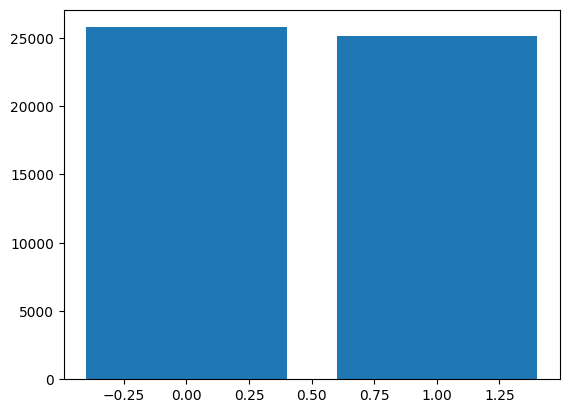

In [30]:
counts = train_df['label'].value_counts()
# print(counts)
# 0    500    ← class 0 appears 500 times
# 1    480    ← class 1 appears 480 times

# print(counts.index)   # [0, 1]    ← your x axis (class labels)
# print(counts.values)  # [500, 480] ← your y axis (how many of each)

plt.bar(counts.index,counts.values)
plt.show()

In [34]:
train_df.describe()

,label
count,50937.000000
mean,0.494081
std,0.499970
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [35]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50937 entries, 0 to 50936
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   images  50937 non-null  str  
 1   label   50937 non-null  int64
dtypes: int64(1), str(1)
memory usage: 796.0 KB


/var/folders/5p/1_5x2py97q7f5d89j76jx20c0000gn/T/ipykernel_11512/948665677.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  image = np.array(image).transpose(1,2,0)


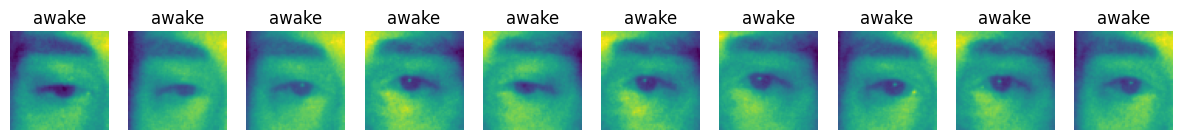

In [46]:
fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for i in range(10):
    image, label = train_data[i]
    image = np.array(image).transpose(1,2,0)
    
    
    axes[i].imshow(image)
    axes[i].set_title(train_data.classes[label])
    axes[i].axis('off')

plt.show()